# 02 — Pemodelan LSTM Unidirectional pada Data Baru (v2)
Notebook ini melatih model LSTM unidirectional pada representasi teks `processed_text_v2`:
- **Arsitektur**: Keras Embedding (10.000, 128) $ightarrow$ LSTM (64 units) $ightarrow$ Dropout (0.2) $ightarrow$ Dense (3, Softmax)
- **Varian**: Natural Baseline dan Cost-Sensitive Class Weight
- **Evaluasi**: Test Set ($n=1.730$) dengan confusion matrix dan classification report.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Lock seed
tf.random.set_seed(42)
np.random.seed(42)

if Path.cwd().name == "notebooks":
    os.chdir("..")


## 1. Load Data v2 dan Tokenisasi


In [2]:
df = pd.read_csv("Data/processed/banjir_processed_v2.csv")
tr_val, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(tr_val, test_size=0.10, stratify=tr_val['label'], random_state=42)

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['processed_text_v2'])

X_tr = pad_sequences(tokenizer.texts_to_sequences(train_df['processed_text_v2']), maxlen=50, padding='post', truncating='post')
X_va = pad_sequences(tokenizer.texts_to_sequences(val_df['processed_text_v2']), maxlen=50, padding='post', truncating='post')
X_te = pad_sequences(tokenizer.texts_to_sequences(test_df['processed_text_v2']), maxlen=50, padding='post', truncating='post')

y_tr = train_df['label'].values
y_va = val_df['label'].values
y_te = test_df['label'].values


## 2. Inisialisasi Model & Training LSTM Baseline


In [3]:
def build_lstm():
    model = Sequential([
        Embedding(10000, 128),
        LSTM(64),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model_base = build_lstm()
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
hist_base = model_base.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=20, batch_size=16, callbacks=[es])


Epoch 1/20


  1/390 ━━━━━━━━━━━━━━━━━━━━ 15:39 2s/step - accuracy: 0.0000e+00 - loss: 1.1185

  5/390 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4125 - loss: 1.0950     

  9/390 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4861 - loss: 1.0862

 13/390 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5385 - loss: 1.0701

...

375/390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8700 - loss: 0.3882

379/390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8707 - loss: 0.3859

383/390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8711 - loss: 0.3852

387/390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8714 - loss: 0.3842

390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8717 - loss: 0.3839 - val_accuracy: 0.6980 - val_loss: 1.0451


## 3. Training LSTM Class Weight


In [4]:
cw_vals = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_tr)
cw_dict = {i: float(cw_vals[i]) for i in range(3)}
print("Bobot Class Weight:", cw_dict)

model_cw = build_lstm()
hist_cw = model_cw.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=20, batch_size=16, class_weight=cw_dict, callbacks=[es])


Bobot Class Weight: {0: 0.6150958308634658, 1: 1.9092302974547686, 2: 1.1758262511803588}
Epoch 1/20


  1/390 ━━━━━━━━━━━━━━━━━━━━ 16:56 3s/step - accuracy: 0.2500 - loss: 1.0055

  5/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4125 - loss: 1.0624 

  9/390 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4375 - loss: 1.0777

 13/390 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4808 - loss: 1.0348

...

378/390 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8312 - loss: 0.4979

382/390 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8313 - loss: 0.4967

386/390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8319 - loss: 0.4958

390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8323 - loss: 0.4953

390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8323 - loss: 0.4953 - val_accuracy: 0.6618 - val_loss: 0.9247


## 4. Evaluasi & Visualisasi


 1/55 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step

 9/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  

16/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

23/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

29/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

...

37/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

47/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


=== HASIL BASELINE LSTM v2 ===
Accuracy: 69.88% | Macro F1: 57.77%

=== HASIL CLASS WEIGHT LSTM v2 ===
Accuracy: 68.15% | Macro F1: 62.56%


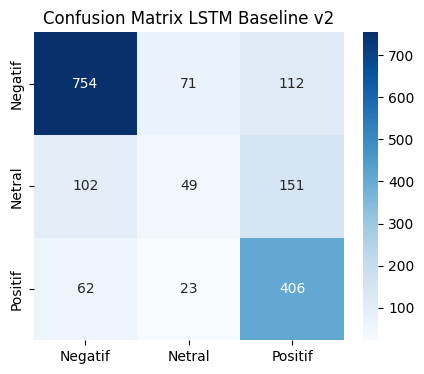

In [5]:
pred_base = np.argmax(model_base.predict(X_te), axis=1)
pred_cw = np.argmax(model_cw.predict(X_te), axis=1)

print("=== HASIL BASELINE LSTM v2 ===")
print(f"Accuracy: {accuracy_score(y_te, pred_base)*100:.2f}% | Macro F1: {f1_score(y_te, pred_base, average='macro')*100:.2f}%")

print("\n=== HASIL CLASS WEIGHT LSTM v2 ===")
print(f"Accuracy: {accuracy_score(y_te, pred_cw)*100:.2f}% | Macro F1: {f1_score(y_te, pred_cw, average='macro')*100:.2f}%")

cm = confusion_matrix(y_te, pred_base)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title("Confusion Matrix LSTM Baseline v2")
plt.show()
